# Predicting Movie Success Categories from IMDB Scores

This notebook builds a complete data analysis and machine learning pipeline for predicting movie success categories from the IMDB movie metadata dataset.

**Target category rules**

- `Flop`: IMDB score from 1 to less than 3
- `Average`: IMDB score from 3 to less than 6
- `Hit`: IMDB score from 6 to 10

The workflow includes EDA, preprocessing, feature engineering, multicollinearity checks, model comparison, Random Forest tuning, evaluation visualizations, artifact export, and optional Streamlit deployment code generation.

## 1. Import Libraries and Configure Notebook

In [1]:
import os
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', palette='Set2')

RANDOM_STATE = 42
DATA_PATH = Path('movie_metadata.csv')
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)


## 2. Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
display(df.head())
display(df.info())


Dataset shape: 5,043 rows x 28 columns


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,4834,Wes Studi,0.0,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220,48350,Jack Davenport,0.0,goddess|marriage ceremony|marriage proposal|pi...,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868,11700,Stephanie Sigman,1.0,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,106759,Joseph Gordon-Levitt,0.0,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens ...,8,143,NaN,0.0,NaN,http://www.imdb.com/title/tt5289954/?ref_=fn_t...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

None

## 3. Initial Data Quality Checks

In [3]:
missing_summary = (
    df.isna().sum()
    .to_frame('missing_count')
    .assign(missing_percent=lambda x: (x['missing_count'] / len(df) * 100).round(2))
    .sort_values('missing_count', ascending=False)
)

duplicate_count = df.duplicated().sum()
print(f'Duplicate rows: {duplicate_count}')
display(missing_summary.head(20))
display(df.describe(include='all').T)


Duplicate rows: 45


,missing_count,missing_percent
gross,884,17.53
budget,492,9.76
aspect_ratio,329,6.52
content_rating,303,6.01
plot_keywords,153,3.03
title_year,108,2.14
director_name,104,2.06
director_facebook_likes,104,2.06
num_critic_for_reviews,50,0.99
actor_3_name,23,0.46


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
color,5024,2,Color,4815,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director_name,4939,2398,Steven Spielberg,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_critic_for_reviews,4993.0,NaN,NaN,NaN,140.194272,121.601675,1.0,50.0,110.0,195.0,813.0
duration,5028.0,NaN,NaN,NaN,107.201074,25.197441,7.0,93.0,103.0,118.0,511.0
director_facebook_likes,4939.0,NaN,NaN,NaN,686.509212,2813.328607,0.0,7.0,49.0,194.5,23000.0
actor_3_facebook_likes,5020.0,NaN,NaN,NaN,645.009761,1665.041728,0.0,133.0,371.5,636.0,23000.0
actor_2_name,5030,3032,Morgan Freeman,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
actor_1_facebook_likes,5036.0,NaN,NaN,NaN,6560.047061,15020.75912,0.0,614.0,988.0,11000.0,640000.0
gross,4159.0,NaN,NaN,NaN,48468407.526809,68452990.438753,162.0,5340987.5,25517500.0,62309437.5,760505847.0
genres,5043,914,Drama,236,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Clean Basic Text Fields and Create Target Class

The raw score is used only to create the class label. It is then removed from the predictive features to avoid target leakage.

In [5]:
data = df.copy()

for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].astype(str).str.strip().replace({'nan': np.nan, 'None': np.nan})

def classify_imdb_score(score):
    if pd.isna(score):
        return np.nan
    if 1 <= score < 3:
        return 'Flop'
    if 3 <= score < 6:
        return 'Average'
    if 6 <= score <= 10:
        return 'Hit'
    return np.nan

data['Classify'] = data['imdb_score'].apply(classify_imdb_score)
data = data.dropna(subset=['Classify']).copy()

class_order = ['Flop', 'Average', 'Hit']
data['Classify'] = pd.Categorical(data['Classify'], categories=class_order, ordered=True)

print(data['Classify'].value_counts().reindex(class_order))
display(data[['movie_title', 'imdb_score', 'Classify']].head(10))


Classify
Flop         41
Average    1413
Hit        3589
Name: count, dtype: int64


,movie_title,imdb_score,Classify
0,Avatar,7.9,Hit
1,Pirates of the Caribbean: At World's End,7.1,Hit
2,Spectre,6.8,Hit
3,The Dark Knight Rises,8.5,Hit
4,Star Wars: Episode VII - The Force Awakens,7.1,Hit
5,John Carter,6.6,Hit
6,Spider-Man 3,6.2,Hit
7,Tangled,7.8,Hit
8,Avengers: Age of Ultron,7.5,Hit
9,Harry Potter and the Half-Blood Prince,7.5,Hit


## 5. Exploratory Data Analysis

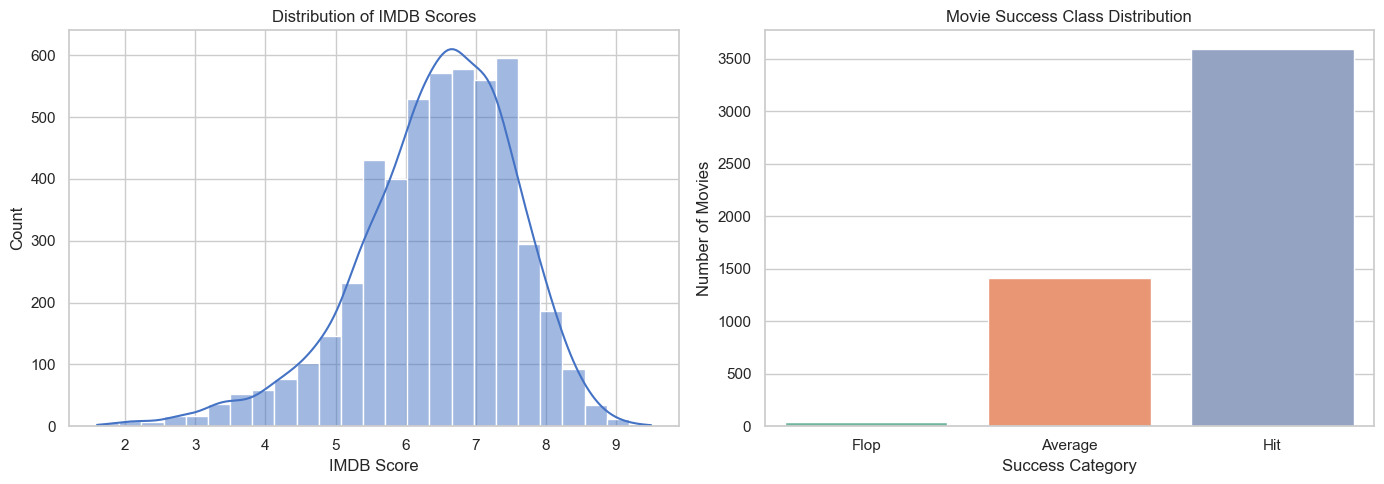

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data['imdb_score'], bins=25, kde=True, ax=axes[0], color='#4472c4')
axes[0].set_title('Distribution of IMDB Scores')
axes[0].set_xlabel('IMDB Score')

sns.countplot(data=data, x='Classify', order=class_order, ax=axes[1], palette='Set2')
axes[1].set_title('Movie Success Class Distribution')
axes[1].set_xlabel('Success Category')
axes[1].set_ylabel('Number of Movies')
plt.tight_layout()
plt.show()


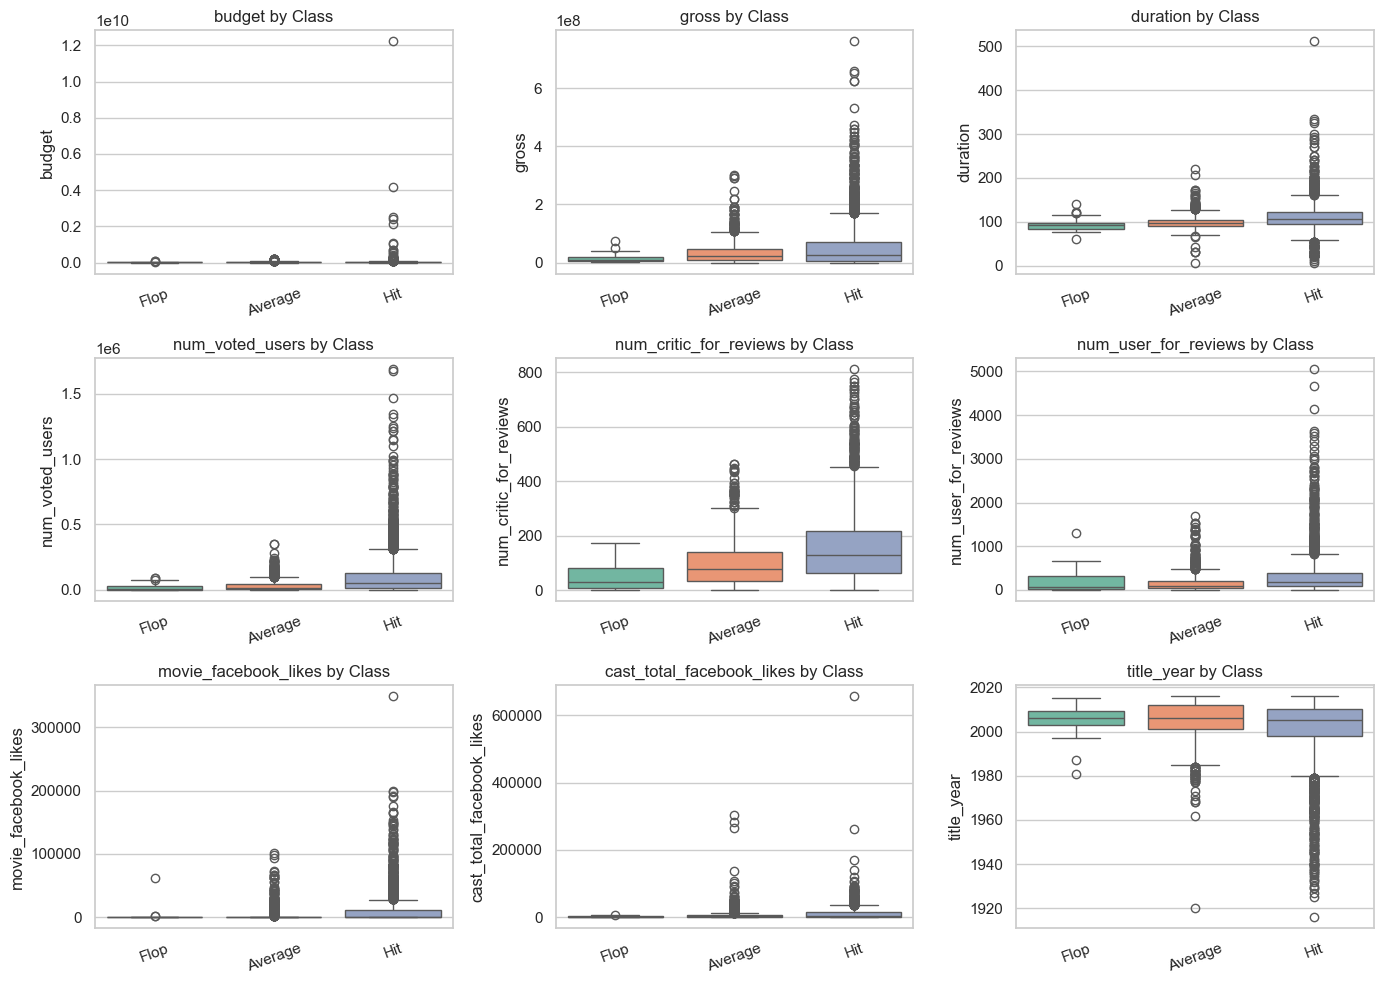

In [7]:
numeric_cols_for_eda = data.select_dtypes(include=np.number).columns.tolist()
important_numeric = [
    'budget', 'gross', 'duration', 'num_voted_users', 'num_critic_for_reviews',
    'num_user_for_reviews', 'movie_facebook_likes', 'cast_total_facebook_likes', 'title_year'
]
important_numeric = [col for col in important_numeric if col in data.columns]

plt.figure(figsize=(14, 10))
for i, col in enumerate(important_numeric, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=data, x='Classify', y=col, order=class_order, palette='Set2')
    plt.title(f'{col} by Class')
    plt.xlabel('')
    plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


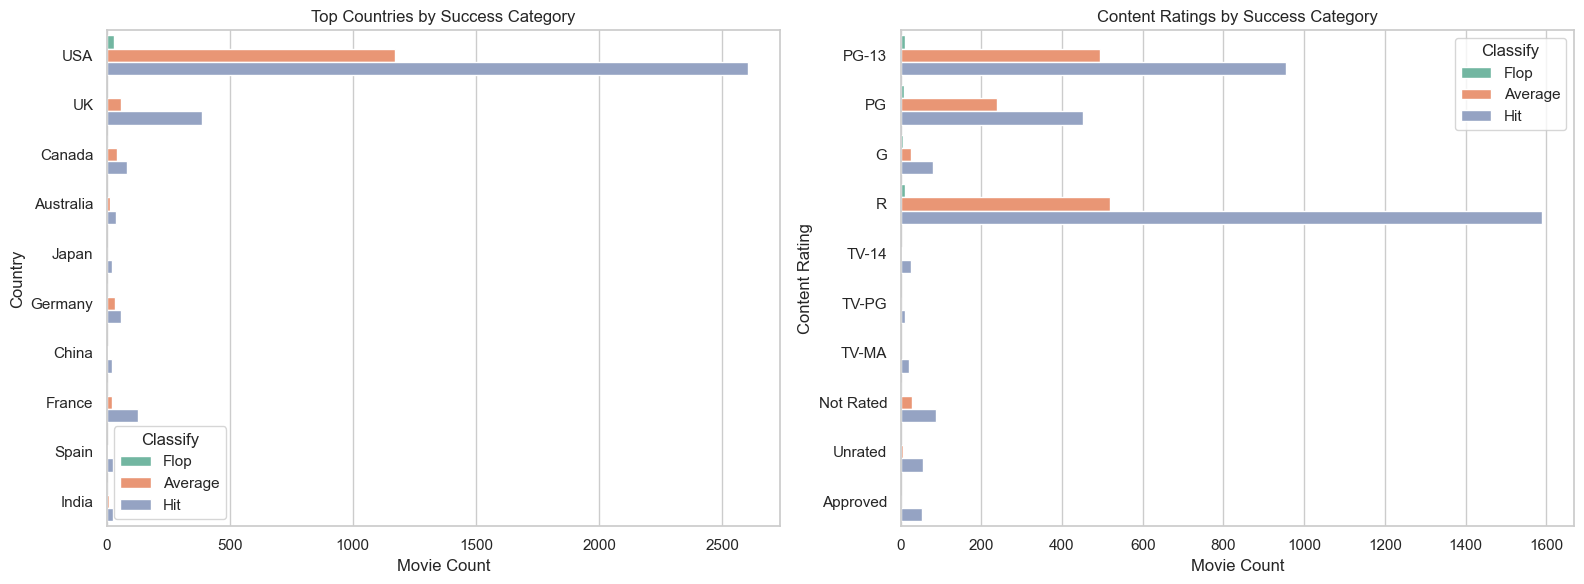

In [8]:
top_countries = data['country'].value_counts().head(10).index
top_ratings = data['content_rating'].value_counts().head(10).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=data[data['country'].isin(top_countries)], y='country', hue='Classify', hue_order=class_order, ax=axes[0], palette='Set2')
axes[0].set_title('Top Countries by Success Category')
axes[0].set_xlabel('Movie Count')
axes[0].set_ylabel('Country')

sns.countplot(data=data[data['content_rating'].isin(top_ratings)], y='content_rating', hue='Classify', hue_order=class_order, ax=axes[1], palette='Set2')
axes[1].set_title('Content Ratings by Success Category')
axes[1].set_xlabel('Movie Count')
axes[1].set_ylabel('Content Rating')
plt.tight_layout()
plt.show()


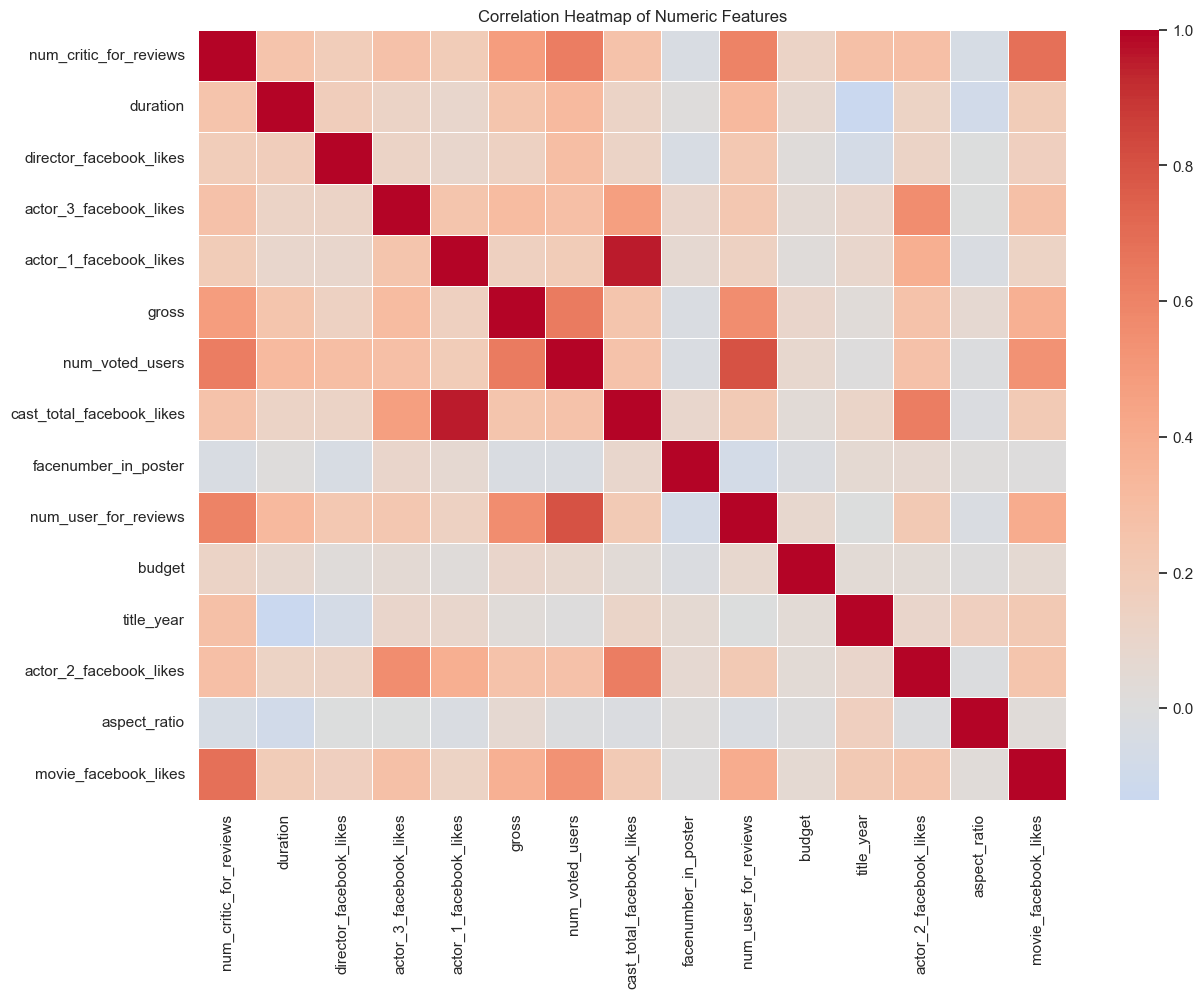

,feature_1,feature_2,correlation
0,actor_1_facebook_likes,cast_total_facebook_likes,0.952


In [10]:
corr_cols = [col for col in numeric_cols_for_eda if col not in ['imdb_score']]
corr = data[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.4)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

high_corr_pairs = []
for i, col_a in enumerate(corr.columns):
    for col_b in corr.columns[i + 1:]:
        value = corr.loc[col_a, col_b]
        if abs(value) >= 0.80:
            high_corr_pairs.append((col_a, col_b, round(value, 3)))

pd.DataFrame(high_corr_pairs, columns=['feature_1', 'feature_2', 'correlation']).sort_values('correlation', key=abs, ascending=False)


## 6. Feature Engineering

The dataset contains multi-value text fields such as `genres` and `plot_keywords`. The pipeline below adds useful engineered features while keeping the original categorical fields available for one-hot encoding.

In [11]:
def engineer_features(input_df):
    engineered = input_df.copy()

    if 'movie_title' not in engineered.columns:
        engineered['movie_title'] = 'Untitled'
    if 'genres' not in engineered.columns:
        engineered['genres'] = 'Unknown'
    if 'plot_keywords' not in engineered.columns:
        engineered['plot_keywords'] = ''

    engineered['movie_title'] = engineered['movie_title'].astype(str).str.strip()
    engineered['genres'] = engineered['genres'].fillna('Unknown')
    engineered['plot_keywords'] = engineered['plot_keywords'].fillna('')

    engineered['genre_count'] = engineered['genres'].apply(lambda x: 0 if pd.isna(x) else len(str(x).split('|')))
    engineered['keyword_count'] = engineered['plot_keywords'].apply(lambda x: 0 if pd.isna(x) or x == '' else len(str(x).split('|')))
    engineered['title_length'] = engineered['movie_title'].apply(lambda x: len(str(x)))
    engineered['main_genre'] = engineered['genres'].apply(lambda x: str(x).split('|')[0] if pd.notna(x) else 'Unknown')

    if {'gross', 'budget'}.issubset(engineered.columns):
        engineered['profit'] = engineered['gross'] - engineered['budget']
        engineered['roi'] = np.where(engineered['budget'] > 0, engineered['gross'] / engineered['budget'], np.nan)

    if 'title_year' in engineered.columns:
        engineered['movie_age'] = 2026 - engineered['title_year']

    return engineered

model_data = engineer_features(data)
display(model_data.head())


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,Classify,genre_count,keyword_count,title_length,main_genre,profit,roi,movie_age
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,4834,Wes Studi,0.0,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000,Hit,4,5,6,Action,523505847.0,3.208885,17.0
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220,48350,Jack Davenport,0.0,goddess|marriage ceremony|marriage proposal|pi...,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0,Hit,3,5,40,Action,9404152.0,1.031347,19.0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868,11700,Stephanie Sigman,1.0,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000,Hit,3,5,7,Action,-44925825.0,0.816629,11.0
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,106759,Joseph Gordon-Levitt,0.0,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000,Hit,2,5,21,Action,198130642.0,1.792523,14.0
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens,8,143,NaN,0.0,,http://www.imdb.com/title/tt5289954/?ref_=fn_t...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0,Hit,1,0,42,Documentary,NaN,NaN,NaN


## 7. Prepare Features and Target

`imdb_score`, `Classify`, movie title, and IMDB link are excluded from training. `imdb_score` is excluded because it directly defines the target class.

In [12]:
target_col = 'Classify'
drop_cols = ['imdb_score', target_col, 'movie_imdb_link', 'movie_title']
drop_cols = [col for col in drop_cols if col in model_data.columns]

X = model_data.drop(columns=drop_cols)
y = model_data[target_col].astype(str)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f'Numeric features: {len(numeric_features)}')
print(numeric_features)
print(f'Categorical features: {len(categorical_features)}')
print(categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')


Numeric features: 21
['num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes', 'aspect_ratio', 'movie_facebook_likes', 'genre_count', 'keyword_count', 'title_length', 'profit', 'roi', 'movie_age']
Categorical features: 11
['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name', 'actor_3_name', 'plot_keywords', 'language', 'country', 'content_rating', 'main_genre']
Train shape: (4034, 32)
Test shape: (1009, 32)


## 8. Build Preprocessing Pipeline

Missing numerical values are filled with the median, categorical values are filled with the most frequent value, and categorical variables are label-expanded using one-hot encoding.

In [13]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=5, sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)


## 9. Compare Multiple Classification Algorithms

In [14]:
models = {
    'Baseline Most Frequent': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVM RBF': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'macro_f1': 'f1_macro', 'weighted_f1': 'f1_weighted'}

results = []
for name, estimator in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', estimator)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, error_score='raise')
    results.append({
        'model': name,
        'cv_accuracy_mean': scores['test_accuracy'].mean(),
        'cv_accuracy_std': scores['test_accuracy'].std(),
        'cv_macro_f1_mean': scores['test_macro_f1'].mean(),
        'cv_macro_f1_std': scores['test_macro_f1'].std(),
        'cv_weighted_f1_mean': scores['test_weighted_f1'].mean(),
        'cv_weighted_f1_std': scores['test_weighted_f1'].std()
    })

results_df = pd.DataFrame(results).sort_values('cv_macro_f1_mean', ascending=False)
display(results_df)
results_df.to_csv(ARTIFACT_DIR / 'model_comparison_results.csv', index=False)


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std
7,SVM RBF,0.754590,0.021835,0.522478,0.031700,0.766219,0.021257
1,Logistic Regression,0.750864,0.007636,0.514017,0.016750,0.764594,0.005329
6,Gradient Boosting,0.791032,0.020576,0.485506,0.011860,0.778618,0.018009
2,KNN,0.754336,0.008337,0.463886,0.005109,0.749433,0.007080
3,Decision Tree,0.720876,0.009589,0.438034,0.010718,0.718436,0.011968
4,Random Forest,0.779625,0.010290,0.436065,0.010362,0.739515,0.011395
5,Extra Trees,0.766982,0.010611,0.423242,0.010443,0.725124,0.012065
0,Baseline Most Frequent,0.711701,0.000532,0.277190,0.000121,0.591830,0.000701


In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='cv_macro_f1_mean', y='model', palette='viridis')
plt.title('Model Comparison by Cross-Validated Macro F1')
plt.xlabel('Mean Macro F1')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


## 10. Tune the Random Forest Model

Random Forest is emphasized because it handles non-linear relationships well, provides feature importance, and is robust for mixed feature sets after preprocessing.

In [15]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 12, 24],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Best parameters:')
print(grid_search.best_params_)
print(f'Best CV macro F1: {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'model__max_depth': 24, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV macro F1: 0.5038


## 11. Evaluate Final Model on Test Set

In [16]:
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average='macro')
test_weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test macro F1: {test_macro_f1:.4f}')
print(f'Test weighted F1: {test_weighted_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, labels=class_order, zero_division=0))

report_dict = classification_report(y_test, y_pred, labels=class_order, output_dict=True, zero_division=0)
pd.DataFrame(report_dict).T.to_csv(ARTIFACT_DIR / 'classification_report.csv')


Test accuracy: 0.8077
Test macro F1: 0.5009
Test weighted F1: 0.7981

Classification Report:
              precision    recall  f1-score   support

        Flop       0.00      0.00      0.00         8
     Average       0.70      0.57      0.63       283
         Hit       0.84      0.91      0.87       718

    accuracy                           0.81      1009
   macro avg       0.51      0.49      0.50      1009
weighted avg       0.79      0.81      0.80      1009



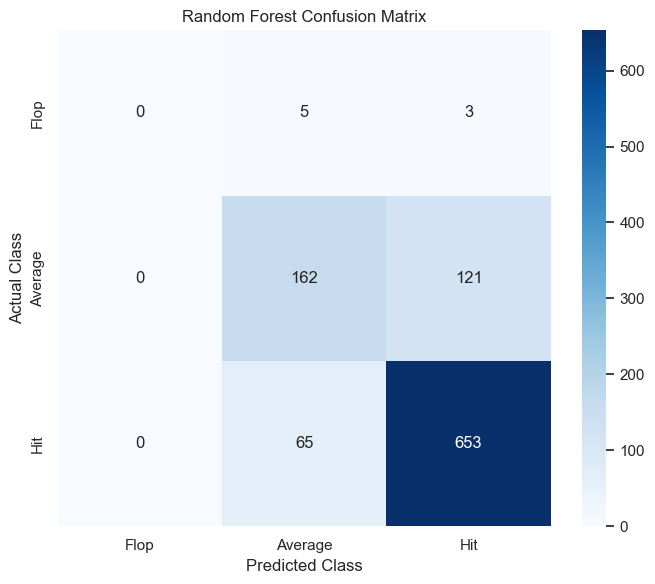

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=class_order)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_order, yticklabels=class_order)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()


## 12. Feature Importance Analysis

,feature,importance
1,num__duration,0.063923
6,num__num_voted_users,0.061521
0,num__num_critic_for_reviews,0.059681
4,num__actor_1_facebook_likes,0.047173
9,num__num_user_for_reviews,0.045835
2,num__director_facebook_likes,0.042596
7,num__cast_total_facebook_likes,0.042230
5,num__gross,0.042149
14,num__movie_facebook_likes,0.036205
12,num__actor_2_facebook_likes,0.035383


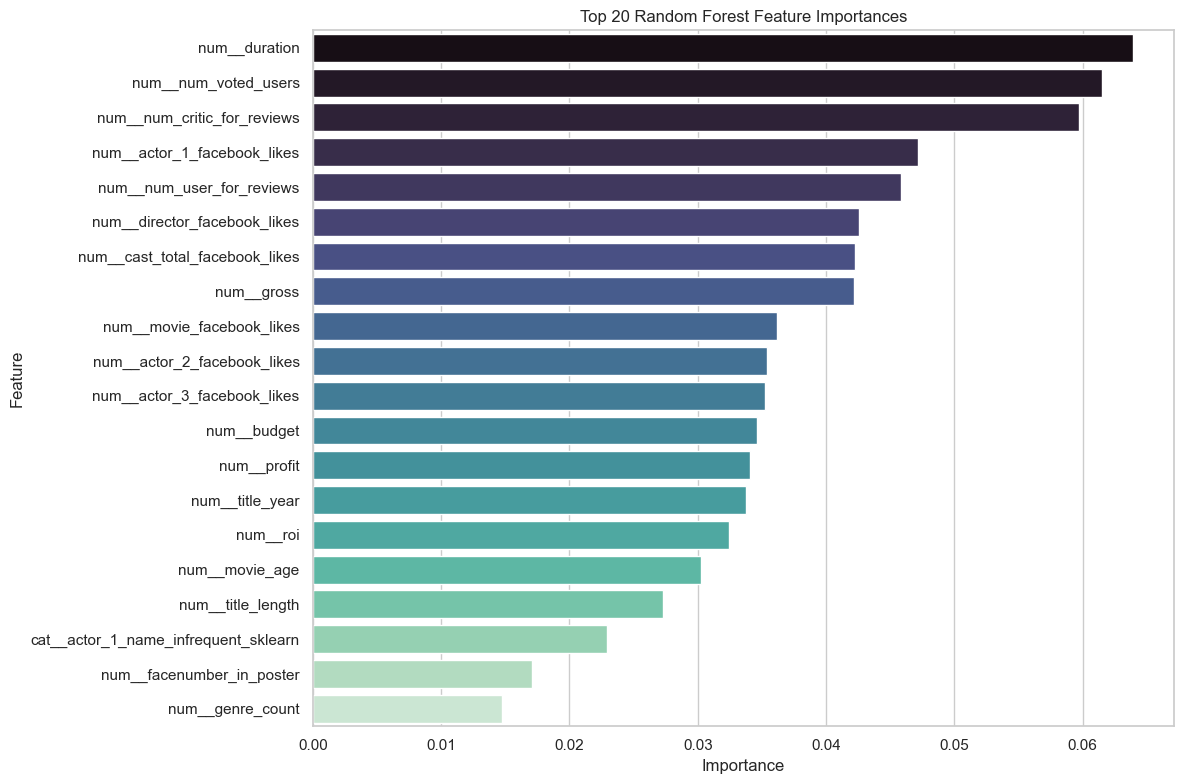

In [18]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
)

display(importance_df.head(25))
importance_df.to_csv(ARTIFACT_DIR / 'random_forest_feature_importance.csv', index=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='mako')
plt.title('Top 20 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 13. Save Model and Prediction Outputs

In [19]:
model_path = ARTIFACT_DIR / 'movie_success_random_forest_model.joblib'
joblib.dump(best_model, model_path)

test_predictions = X_test.copy()
test_predictions['actual_class'] = y_test.values
test_predictions['predicted_class'] = y_pred

if hasattr(best_model.named_steps['model'], 'predict_proba'):
    probabilities = best_model.predict_proba(X_test)
    for class_name, class_prob in zip(best_model.named_steps['model'].classes_, probabilities.T):
        test_predictions[f'probability_{class_name}'] = class_prob

test_predictions.to_csv(ARTIFACT_DIR / 'test_predictions.csv', index=False)

dashboard_export = model_data.copy()
dashboard_features = dashboard_export.drop(columns=drop_cols)
dashboard_export['predicted_class'] = best_model.predict(dashboard_features)
dashboard_export.to_csv(ARTIFACT_DIR / 'movie_success_dashboard_export.csv', index=False)

metadata = {
    'model_path': str(model_path),
    'target_column': target_col,
    'classes': class_order,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'dropped_columns': drop_cols,
    'test_accuracy': test_accuracy,
    'test_macro_f1': test_macro_f1,
    'test_weighted_f1': test_weighted_f1,
    'best_params': grid_search.best_params_
}

with open(ARTIFACT_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print(f'Saved trained model to: {model_path}')
print('Saved model comparison, classification report, feature importance, predictions, and dashboard export to artifacts/.')


Saved trained model to: artifacts\movie_success_random_forest_model.joblib
Saved model comparison, classification report, feature importance, predictions, and dashboard export to artifacts/.


## 14. Single-Movie Prediction Helper

In [20]:
def predict_movie_success(movie_attributes, trained_model=best_model):
    """Predict movie success class for a dictionary of movie attributes."""
    input_frame = pd.DataFrame([movie_attributes])
    input_frame = engineer_features(input_frame)
    input_frame = input_frame.reindex(columns=X.columns)
    prediction = trained_model.predict(input_frame)[0]
    probabilities = trained_model.predict_proba(input_frame)[0]
    probability_map = dict(zip(trained_model.named_steps['model'].classes_, probabilities.round(4)))
    return prediction, probability_map

sample_movie = X_test.iloc[0].to_dict()
predicted_class, predicted_probabilities = predict_movie_success(sample_movie)
print('Predicted class:', predicted_class)
print('Class probabilities:', predicted_probabilities)


Predicted class: Average
Class probabilities: {'Average': 0.6309, 'Flop': 0.1011, 'Hit': 0.268}


## 15. Generate Optional Streamlit Deployment File

Run this cell after the model artifact is saved. Then launch the app from a terminal with:

```bash
streamlit run streamlit_app.py
```

In [21]:
streamlit_code = r'''
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import streamlit as st

ARTIFACT_DIR = Path('artifacts')
MODEL_PATH = ARTIFACT_DIR / 'movie_success_random_forest_model.joblib'
METADATA_PATH = ARTIFACT_DIR / 'model_metadata.json'

def engineer_features(input_df):
    engineered = input_df.copy()
    engineered['movie_title'] = engineered.get('movie_title', pd.Series(['Untitled'])).astype(str).str.strip()
    engineered['genres'] = engineered.get('genres', pd.Series(['Unknown'])).fillna('Unknown')
    engineered['plot_keywords'] = engineered.get('plot_keywords', pd.Series([''])).fillna('')
    engineered['genre_count'] = engineered['genres'].apply(lambda x: 0 if pd.isna(x) else len(str(x).split('|')))
    engineered['keyword_count'] = engineered['plot_keywords'].apply(lambda x: 0 if pd.isna(x) or x == '' else len(str(x).split('|')))
    engineered['title_length'] = engineered['movie_title'].apply(lambda x: len(str(x)))
    engineered['main_genre'] = engineered['genres'].apply(lambda x: str(x).split('|')[0] if pd.notna(x) else 'Unknown')
    if {'gross', 'budget'}.issubset(engineered.columns):
        engineered['profit'] = engineered['gross'] - engineered['budget']
        engineered['roi'] = np.where(engineered['budget'] > 0, engineered['gross'] / engineered['budget'], np.nan)
    if 'title_year' in engineered.columns:
        engineered['movie_age'] = 2026 - engineered['title_year']
    return engineered

@st.cache_resource
def load_assets():
    model = joblib.load(MODEL_PATH)
    with open(METADATA_PATH, 'r') as f:
        metadata = json.load(f)
    return model, metadata

st.set_page_config(page_title='Movie Success Predictor', layout='wide')
st.title('Movie Success Predictor')

model, metadata = load_assets()

with st.form('movie_form'):
    col1, col2, col3 = st.columns(3)
    with col1:
        movie_title = st.text_input('Movie title', 'New Movie')
        genres = st.text_input('Genres', 'Action|Adventure')
        director_name = st.text_input('Director name', 'Unknown')
        actor_1_name = st.text_input('Lead actor', 'Unknown')
        language = st.text_input('Language', 'English')
    with col2:
        country = st.text_input('Country', 'USA')
        content_rating = st.selectbox('Content rating', ['G', 'PG', 'PG-13', 'R', 'Not Rated'])
        title_year = st.number_input('Title year', min_value=1900, max_value=2026, value=2026)
        duration = st.number_input('Duration minutes', min_value=1, value=110)
        aspect_ratio = st.number_input('Aspect ratio', min_value=0.5, value=2.35)
    with col3:
        budget = st.number_input('Budget', min_value=0.0, value=50000000.0, step=1000000.0)
        gross = st.number_input('Gross revenue', min_value=0.0, value=80000000.0, step=1000000.0)
        num_voted_users = st.number_input('Voted users', min_value=0, value=50000)
        num_critic_for_reviews = st.number_input('Critic reviews', min_value=0, value=150)
        movie_facebook_likes = st.number_input('Movie Facebook likes', min_value=0, value=10000)

    submitted = st.form_submit_button('Predict success')

if submitted:
    input_data = {
        'color': 'Color',
        'director_name': director_name,
        'num_critic_for_reviews': num_critic_for_reviews,
        'duration': duration,
        'director_facebook_likes': 0,
        'actor_3_facebook_likes': 0,
        'actor_2_name': 'Unknown',
        'actor_1_facebook_likes': 0,
        'gross': gross,
        'genres': genres,
        'actor_1_name': actor_1_name,
        'movie_title': movie_title,
        'num_voted_users': num_voted_users,
        'cast_total_facebook_likes': 0,
        'actor_3_name': 'Unknown',
        'facenumber_in_poster': 0,
        'plot_keywords': '',
        'num_user_for_reviews': 0,
        'language': language,
        'country': country,
        'content_rating': content_rating,
        'budget': budget,
        'title_year': title_year,
        'actor_2_facebook_likes': 0,
        'aspect_ratio': aspect_ratio,
        'movie_facebook_likes': movie_facebook_likes
    }

    input_frame = engineer_features(pd.DataFrame([input_data]))
    feature_columns = metadata['numeric_features'] + metadata['categorical_features']
    input_frame = input_frame.reindex(columns=feature_columns)

    prediction = model.predict(input_frame)[0]
    probabilities = model.predict_proba(input_frame)[0]
    probability_df = pd.DataFrame({'Class': model.named_steps['model'].classes_, 'Probability': probabilities})

    st.subheader(f'Predicted result: {prediction}')
    st.bar_chart(probability_df.set_index('Class'))
'''

with open('streamlit_app.py', 'w') as f:
    f.write(streamlit_code)

print('Created streamlit_app.py')


Created streamlit_app.py


## 16. PowerBI/Tableau Dashboard Suggestions

Use `artifacts/movie_success_dashboard_export.csv` as the dashboard source file. Recommended visuals:

- Success category count by country, content rating, language, and main genre
- Budget, gross revenue, ROI, and profit by predicted class
- Top directors and actors by number of predicted hit movies
- Year-wise trend of movie success classes
- Model prediction comparison: actual class vs predicted class
- Filters for country, language, content rating, genre, title year, and director